In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [12]:
df = pd.read_csv(r"C:\MASTERS\FOML\202618026_AumTailor_DS605\202618026_lab_04\AB_NYC_2019.csv")
print(df.shape)
df.head()

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [13]:
df.info()
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nPrice stats:\n", df["price"].describe())

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

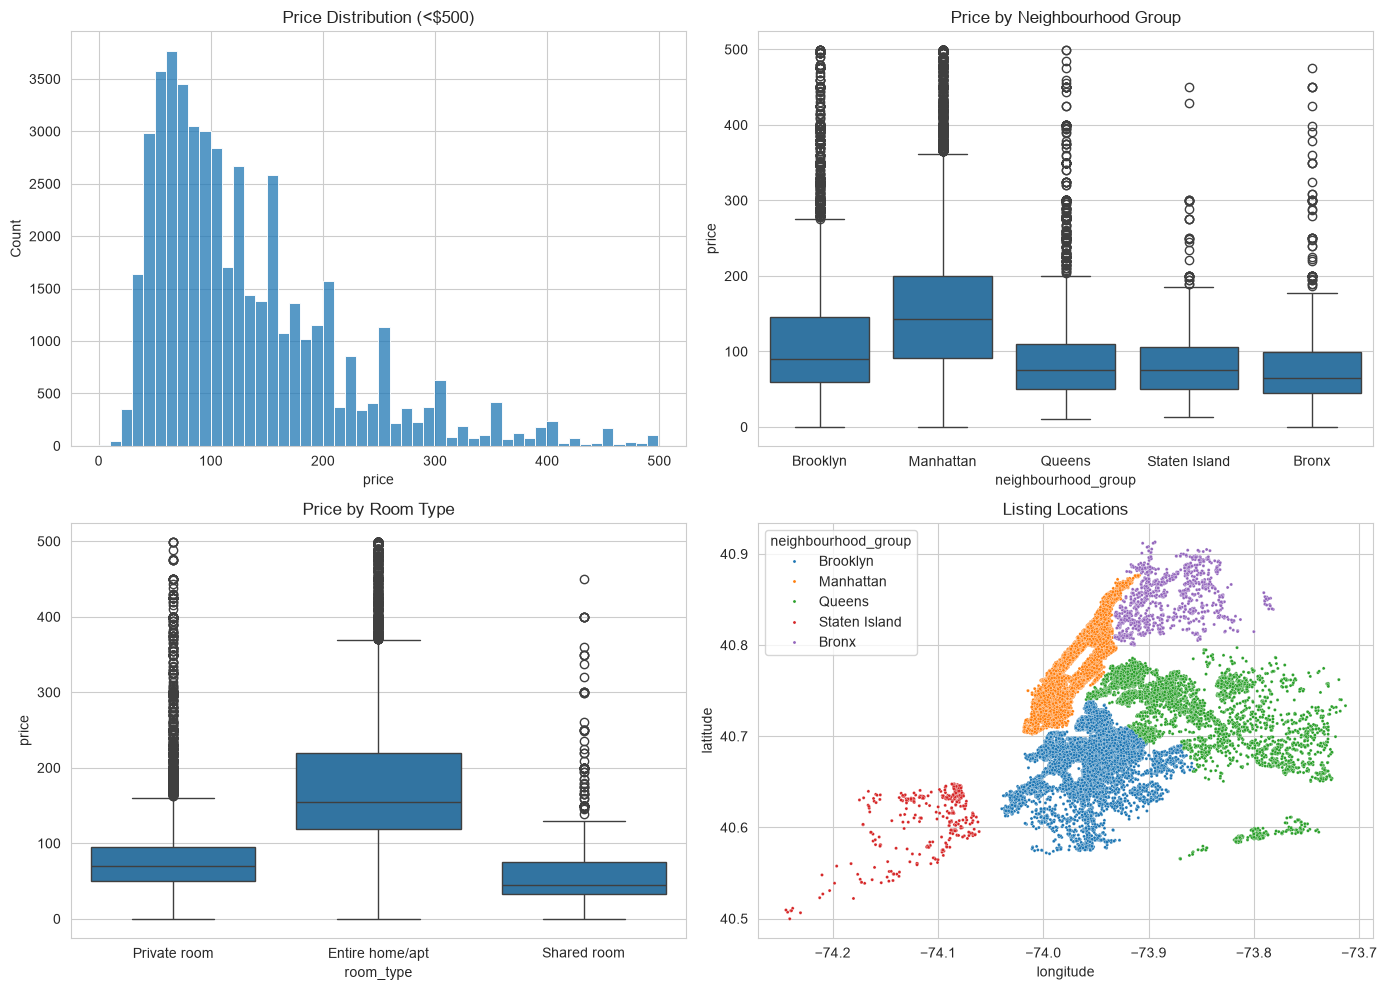

In [14]:
import os
os.makedirs("assets", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df[df["price"] < 500]["price"], bins=50, ax=axes[0,0])
axes[0,0].set_title("Price Distribution (<$500)")

sns.boxplot(x="neighbourhood_group", y="price", data=df[df["price"] < 500], ax=axes[0,1])
axes[0,1].set_title("Price by Neighbourhood Group")

sns.boxplot(x="room_type", y="price", data=df[df["price"] < 500], ax=axes[1,0])
axes[1,0].set_title("Price by Room Type")

sns.scatterplot(x="longitude", y="latitude", hue="neighbourhood_group",
                 data=df, s=5, ax=axes[1,1])
axes[1,1].set_title("Listing Locations")

plt.tight_layout()
plt.savefig("assets/eda_overview.png", dpi=120)
plt.show()

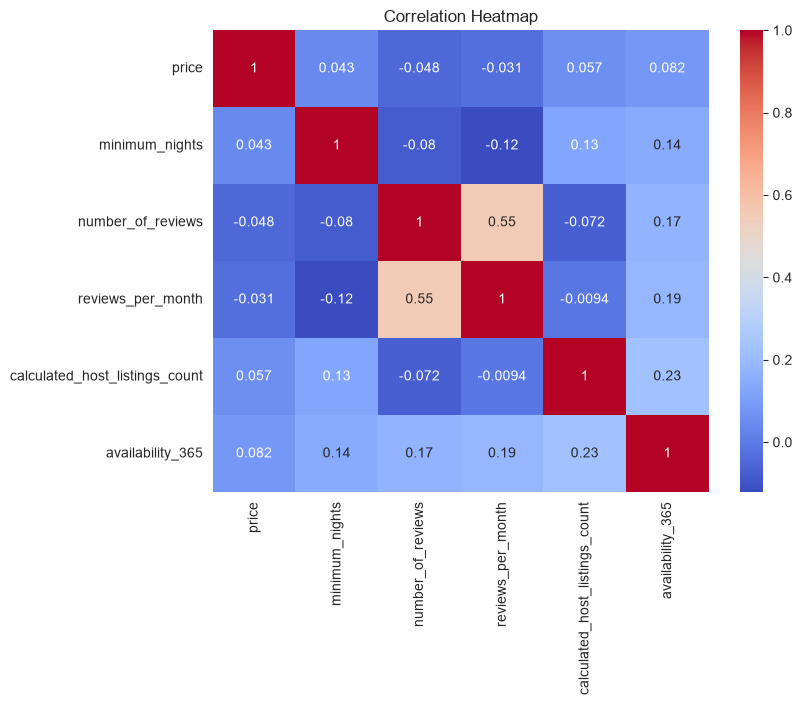

In [15]:
plt.figure(figsize=(8,6))
corr_cols = ["price","minimum_nights","number_of_reviews","reviews_per_month",
             "calculated_host_listings_count","availability_365"]
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("assets/correlation_heatmap.png", dpi=120)
plt.show()

In [16]:
# Drop listings with price = 0 (not real prices)
df = df[df["price"] > 0].copy()

# reviews_per_month: NaN means no reviews yet -> 0
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# name / host_name: fill NaN, not used as model features anyway
df["name"] = df["name"].fillna("Unknown")
df["host_name"] = df["host_name"].fillna("Unknown")

# last_review: convert to "days since last review"; missing -> no reviews yet
df["last_review"] = pd.to_datetime(df["last_review"])
reference_date = df["last_review"].max()
df["days_since_last_review"] = (reference_date - df["last_review"]).dt.days
df["days_since_last_review"] = df["days_since_last_review"].fillna(
    df["days_since_last_review"].max() + 1  # older than any real review
)

print(df.isnull().sum()[df.isnull().sum() > 0])

last_review    10051
dtype: int64


In [17]:
# Cap price at 99th percentile to remove extreme luxury outliers
price_cap = df["price"].quantile(0.99)
df = df[df["price"] <= price_cap]

# Cap minimum_nights at a realistic value (some listings have 1000+ nights)
df["minimum_nights"] = df["minimum_nights"].clip(upper=30)

# Log-transform target to reduce skew (we'll inverse-transform predictions later)
df["log_price"] = np.log1p(df["price"])

print("Rows after outlier removal:", df.shape[0])
print("Price cap used:", price_cap)

Rows after outlier removal: 48410
Price cap used: 799.0


In [18]:
features = [
    "neighbourhood_group", "neighbourhood", "room_type",
    "latitude", "longitude", "minimum_nights", "number_of_reviews",
    "reviews_per_month", "calculated_host_listings_count",
    "availability_365", "days_since_last_review"
]
target = "log_price"

X = df[features].copy()
y = df[target].copy()

categorical_features = ["neighbourhood_group", "neighbourhood", "room_type"]
numeric_features = [c for c in features if c not in categorical_features]

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)

Categorical: ['neighbourhood_group', 'neighbourhood', 'room_type']
Numeric: ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'days_since_last_review']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [14]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_mae = mean_absolute_error(y_test, test_pred)

    results.append({
        "Model": name, "Train_R2": train_r2, "Test_R2": test_r2,
        "Test_RMSE": test_rmse, "Test_MAE": test_mae
    })

results_df = pd.DataFrame(results).sort_values("Test_R2", ascending=False)
print(results_df)

              Model  Train_R2   Test_R2  Test_RMSE  Test_MAE
2      RandomForest  0.950327  0.647169   0.386888  0.288354
3  GradientBoosting  0.628965  0.627346   0.397608  0.300166
1             Ridge  0.597373  0.597328   0.413312  0.313463
0  LinearRegression  0.597530  0.596940   0.413511  0.313595


In [15]:
best_model_name = results_df.iloc[0]["Model"]
print("Best baseline model:", best_model_name)

# Tune RandomForest (swap in GradientBoostingRegressor() if that wins instead)
tuned_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

search = RandomizedSearchCV(
    tuned_pipe, param_distributions=param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
final_model = search.best_estimator_

Best baseline model: RandomForest
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}


=== FINAL MODEL PERFORMANCE (log_price scale) ===
Train R2: 0.9502578612180176
Test R2: 0.64662795868795
Test RMSE: 0.3871847725100874
Test MAE: 0.28898528560417547

=== FINAL MODEL PERFORMANCE (actual $ scale) ===
RMSE ($): 74.06885852997996
MAE ($): 42.19999045081659


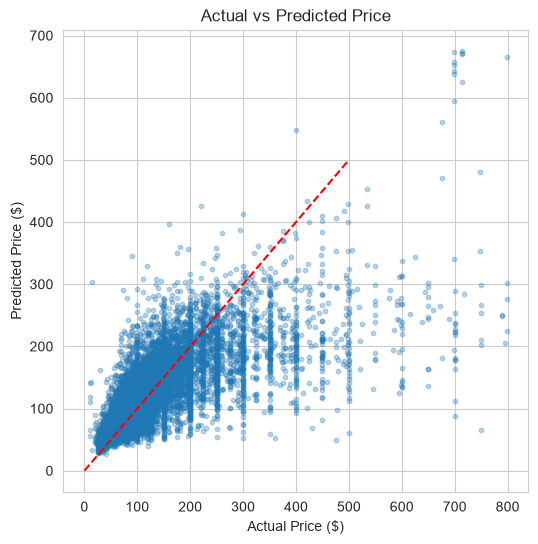

In [16]:
train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

print("=== FINAL MODEL PERFORMANCE (log_price scale) ===")
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))
print("Test MAE:", mean_absolute_error(y_test, test_pred))

# Convert back to real dollar scale for interpretability
test_pred_dollars = np.expm1(test_pred)
y_test_dollars = np.expm1(y_test)
print("\n=== FINAL MODEL PERFORMANCE (actual $ scale) ===")
print("RMSE ($):", np.sqrt(mean_squared_error(y_test_dollars, test_pred_dollars)))
print("MAE ($):", mean_absolute_error(y_test_dollars, test_pred_dollars))

plt.figure(figsize=(6,6))
plt.scatter(y_test_dollars, test_pred_dollars, alpha=0.3, s=10)
plt.plot([0, 500], [0, 500], "r--")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Price")
plt.savefig("assets/actual_vs_predicted.png", dpi=120)
plt.show()

In [17]:
best_model_name = results_df.iloc[0]["Model"]
print("Best baseline model:", best_model_name)

# Constrain depth/leaf-size much more aggressively to fight overfitting
tuned_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 8, 10, 12],          # much shallower than before
    "model__min_samples_split": [10, 20, 30],
    "model__min_samples_leaf": [5, 10, 20],       # bigger leaves = less overfitting
    "model__max_features": ["sqrt", "log2", 0.5]
}

search = RandomizedSearchCV(
    tuned_pipe, param_distributions=param_dist,
    n_iter=20, cv=5, scoring="r2", random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
final_model = search.best_estimator_

# Sanity check the gap immediately
train_r2_check = r2_score(y_train, final_model.predict(X_train))
test_r2_check = r2_score(y_test, final_model.predict(X_test))
print(f"Train R2: {train_r2_check:.4f} | Test R2: {test_r2_check:.4f} | Gap: {train_r2_check - test_r2_check:.4f}")

Best baseline model: RandomForest
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__n_estimators': 300, 'model__min_samples_split': 20, 'model__min_samples_leaf': 5, 'model__max_features': 0.5, 'model__max_depth': 12}
Train R2: 0.7001 | Test R2: 0.6475 | Gap: 0.0526


In [18]:
gb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__min_samples_leaf": [5, 10, 20]
}

gb_search = RandomizedSearchCV(
    gb_pipe, param_distributions=gb_param_dist,
    n_iter=20, cv=5, scoring="r2", random_state=42, n_jobs=-1, verbose=1
)
gb_search.fit(X_train, y_train)

gb_train_r2 = r2_score(y_train, gb_search.best_estimator_.predict(X_train))
gb_test_r2 = r2_score(y_test, gb_search.best_estimator_.predict(X_test))
print(f"GB Train R2: {gb_train_r2:.4f} | Test R2: {gb_test_r2:.4f}")

# Pick whichever model has the better (higher) test R2 with a smaller train/test gap
if gb_test_r2 >= test_r2_check:
    final_model = gb_search.best_estimator_
    print("Using tuned GradientBoosting as final model")
else:
    print("Using tuned RandomForest as final model")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
GB Train R2: 0.6691 | Test R2: 0.6469
Using tuned RandomForest as final model


In [19]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ---------- Random Forest objective ----------
def objective_rf(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 400)
    max_depth = trial.suggest_int("max_depth", 4, 15)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 30)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.7])

    model = RandomForestRegressor(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
        max_features=max_features, random_state=42, n_jobs=-1
    )
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
    return scores.mean()

# ---------- Gradient Boosting objective ----------
def objective_gb(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 400)
    max_depth = trial.suggest_int("max_depth", 2, 6)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    model = GradientBoostingRegressor(
        n_estimators=n_estimators, max_depth=max_depth,
        learning_rate=learning_rate, subsample=subsample,
        min_samples_leaf=min_samples_leaf, random_state=42
    )
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
    return scores.mean()

# ---------- Run both studies ----------
print("Running Optuna on Random Forest...")
study_rf = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)

print("\nRunning Optuna on Gradient Boosting...")
study_gb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_gb.optimize(objective_gb, n_trials=30, show_progress_bar=True)

# ---------- Fit both best models on full train set ----------
optuna_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1))
])
optuna_rf.fit(X_train, y_train)

optuna_gb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(**study_gb.best_params, random_state=42))
])
optuna_gb.fit(X_train, y_train)

# ---------- Evaluate both ----------
rf_train_r2 = r2_score(y_train, optuna_rf.predict(X_train))
rf_test_r2 = r2_score(y_test, optuna_rf.predict(X_test))
gb_train_r2 = r2_score(y_train, optuna_gb.predict(X_train))
gb_test_r2 = r2_score(y_test, optuna_gb.predict(X_test))

comparison_optuna = pd.DataFrame([
    {"Model": "RandomForest (Optuna)", "Train_R2": rf_train_r2, "Test_R2": rf_test_r2, "Gap": rf_train_r2 - rf_test_r2},
    {"Model": "GradientBoosting (Optuna)", "Train_R2": gb_train_r2, "Test_R2": gb_test_r2, "Gap": gb_train_r2 - gb_test_r2},
])
print(comparison_optuna)

# ---------- Pick the model with better test R2 and smaller gap ----------
if gb_test_r2 >= rf_test_r2:
    final_model = optuna_gb
    print("\nSelected: Optuna-tuned Gradient Boosting as final model")
else:
    final_model = optuna_rf
    print("\nSelected: Optuna-tuned Random Forest as final model")

[I 2026-09-14 16:36:26,630] A new study created in memory with name: no-name-c0eb86a9-75d7-448c-b5cc-49516ca4ad8c


Running Optuna on Random Forest...


Best trial: 0. Best value: 0.638021:   3%|▎         | 1/30 [00:43<20:51, 43.16s/it]

[I 2026-09-14 16:37:09,785] Trial 0 finished with value: 0.6380205388662803 and parameters: {'n_estimators': 212, 'max_depth': 15, 'min_samples_split': 23, 'min_samples_leaf': 12, 'max_features': 0.7}. Best is trial 0 with value: 0.6380205388662803.


Best trial: 0. Best value: 0.638021:   7%|▋         | 2/30 [00:48<09:50, 21.09s/it]

...

[I 2026-09-14 17:09:33,412] Trial 27 finished with value: 0.6440424836326061 and parameters: {'n_estimators': 313, 'max_depth': 6, 'learning_rate': 0.05016883214780539, 'subsample': 0.8852932984884809, 'min_samples_leaf': 17}. Best is trial 25 with value: 0.6454235387711825.


Best trial: 28. Best value: 0.646273:  97%|█████████▋| 29/30 [15:27<00:46, 46.85s/it]

[I 2026-09-14 17:10:26,738] Trial 28 finished with value: 0.6462730894712634 and parameters: {'n_estimators': 396, 'max_depth': 6, 'learning_rate': 0.07955102802742788, 'subsample': 0.9084758819863101, 'min_samples_leaf': 10}. Best is trial 28 with value: 0.6462730894712634.


Best trial: 28. Best value: 0.646273: 100%|██████████| 30/30 [16:21<00:00, 32.71s/it]


[I 2026-09-14 17:11:20,273] Trial 29 finished with value: 0.6449381263617067 and parameters: {'n_estimators': 375, 'max_depth': 6, 'learning_rate': 0.09069267230158859, 'subsample': 0.9517890875185224, 'min_samples_leaf': 9}. Best is trial 28 with value: 0.6462730894712634.
                       Model  Train_R2   Test_R2       Gap
0      RandomForest (Optuna)  0.745589  0.651582  0.094007
1  GradientBoosting (Optuna)  0.721305  0.656087  0.065218

Selected: Optuna-tuned Gradient Boosting as final model


In [20]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Exact best params from Trial 28 (your best Optuna trial, CV R2 = 0.646273)
best_gb_params = {
    "n_estimators": 396,
    "max_depth": 6,
    "learning_rate": 0.07955102802742788,
    "subsample": 0.9084758819863101,
    "min_samples_leaf": 10
}

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(**best_gb_params, random_state=42))
])
final_model.fit(X_train, y_train)

train_r2 = r2_score(y_train, final_model.predict(X_train))
test_r2 = r2_score(y_test, final_model.predict(X_test))
print(f"Final Model (GradientBoosting, Optuna params) -> Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f} | Gap: {train_r2-test_r2:.4f}")

Final Model (GradientBoosting, Optuna params) -> Train R2: 0.7213 | Test R2: 0.6561 | Gap: 0.0652


In [21]:
import os
os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "models/airbnb_price_model.pkl")

category_options = {
    "neighbourhood_group": sorted(df["neighbourhood_group"].unique().tolist()),
    "neighbourhood": sorted(df["neighbourhood"].unique().tolist()),
    "room_type": sorted(df["room_type"].unique().tolist())
}
joblib.dump(category_options, "models/category_options.pkl")

print("Model saved to /models — safe from future crashes")

Model saved to /models — safe from future crashes


=== FINAL MODEL PERFORMANCE (actual $ scale) ===
RMSE ($): 73.17145551986484
MAE ($): 41.93646827520091


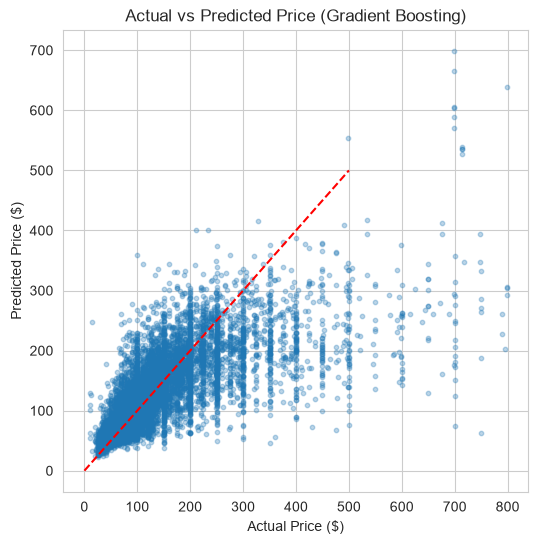

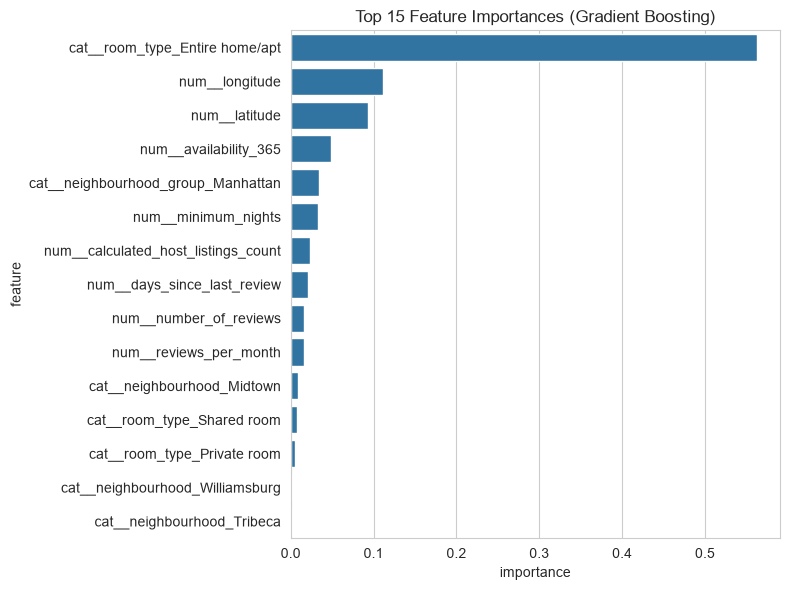

,feature,importance
231,cat__room_type_Entire home/apt,0.562379
1,num__longitude,0.111142
0,num__latitude,0.093491
6,num__availability_365,0.048913
10,cat__neighbourhood_group_Manhattan,0.034432
2,num__minimum_nights,0.033319
5,num__calculated_host_listings_count,0.022807
7,num__days_since_last_review,0.020753
3,num__number_of_reviews,0.016578
4,num__reviews_per_month,0.015435


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

os.makedirs("assets", exist_ok=True)

test_pred = final_model.predict(X_test)
test_pred_dollars = np.expm1(test_pred)
y_test_dollars = np.expm1(y_test)

print("=== FINAL MODEL PERFORMANCE (actual $ scale) ===")
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("RMSE ($):", np.sqrt(mean_squared_error(y_test_dollars, test_pred_dollars)))
print("MAE ($):", mean_absolute_error(y_test_dollars, test_pred_dollars))

plt.figure(figsize=(6,6))
plt.scatter(y_test_dollars, test_pred_dollars, alpha=0.3, s=10)
plt.plot([0, 500], [0, 500], "r--")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Price (Gradient Boosting)")
plt.savefig("assets/actual_vs_predicted.png", dpi=120)
plt.show()

# Feature importance
importances = final_model.named_steps["model"].feature_importances_
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x="importance", y="feature", data=importance_df)
plt.title("Top 15 Feature Importances (Gradient Boosting)")
plt.tight_layout()
plt.savefig("assets/feature_importance.png", dpi=120)
plt.show()

importance_df